# Análise do Mercado de Videogames para Planejamento Estratégico de Marketing

## Introdução

A indústria global de videogames é altamente competitiva e passa por constantes transformações, com o surgimento de novas plataformas, mudanças no comportamento dos consumidores e evolução dos gêneros de jogos ao longo do tempo. Nesse contexto, compreender os fatores que influenciam o sucesso comercial de um jogo é fundamental para orientar decisões estratégicas de marketing e investimento.

Neste estudo de caso, serão analisados dados históricos de vendas de videogames disponibilizados pela loja online Ice, que comercializa jogos em diferentes regiões do mundo. O conjunto de dados inclui informações sobre plataformas, gêneros, vendas regionais, além de avaliações de críticos e usuários.

O objetivo da análise é identificar padrões que possam ajudar a compreender quais características estão associadas ao desempenho comercial dos jogos. Esses insights podem contribuir para identificar tendências de mercado, avaliar o potencial de diferentes plataformas e gêneros e compreender possíveis fatores que impactam as vendas.

Para fins analíticos, consideraremos um cenário hipotético no qual estamos no final de 2016 e precisamos utilizar os dados disponíveis até esse momento para apoiar o planejamento de campanhas e decisões estratégicas para o período seguinte.

Embora se trate de um estudo de caso educacional, a análise será conduzida utilizando práticas comuns em projetos de análise de dados, incluindo preparação e limpeza de dados, análise exploratória, visualização de informações, construção de perfis de mercado regionais e testes estatísticos de hipóteses.

## Visão Geral dos Dados

Antes de iniciar qualquer etapa de preparação ou análise, é importante compreender a estrutura geral do conjunto de dados.

Nesta etapa inicial, iremos carregar o dataset e realizar uma inspeção preliminar para entender:

- quais variáveis estão disponíveis
- como os dados estão estruturados
- quais são os tipos de dados de cada coluna
- se existem valores ausentes

Essa etapa é fundamental em projetos de análise de dados, pois permite identificar possíveis inconsistências ou limitações no conjunto de dados antes de iniciar a etapa de preparação e análise.

In [106]:
# importar dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
# leitura do arquivo
df = pd.read_csv('/datasets/games.csv')

In [108]:
# visualização inicial
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [109]:
# estrutura dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [110]:
# estatisticas
df.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [111]:
# dimensões
df.shape

(16715, 11)

### Observações iniciais sobre o conjunto de dados

O conjunto de dados contém **16.715 registros** e **11 colunas**, representando informações sobre jogos lançados em diferentes plataformas ao longo do tempo.

Entre as principais variáveis disponíveis estão:

- **Name**: nome do jogo
- **Platform**: plataforma em que o jogo foi lançado
- **Year_of_Release**: ano de lançamento
- **Genre**: gênero do jogo
- **NA_sales, EU_sales, JP_sales e Other_sales**: vendas em milhões de dólares nas diferentes regiões
- **Critic_Score**: avaliação média de críticos especializados
- **User_Score**: avaliação média atribuída pelos usuários
- **Rating**: classificação etária atribuída pelo ESRB

A análise inicial também indica a presença de **valores ausentes em algumas colunas**, especialmente em `Year_of_Release`, `Critic_Score`, `User_Score` e `Rating`. Isso pode ocorrer porque alguns jogos não possuem avaliações registradas ou porque determinadas informações não estavam disponíveis no momento da coleta dos dados.

Outro ponto importante é que a coluna `User_Score` aparece com o tipo **object**, o que indica que alguns valores podem estar armazenados como texto (por exemplo, a abreviação **TBD – "to be determined"**). Esse aspecto será tratado na etapa de preparação dos dados.

Com essa visão geral do dataset, podemos seguir para a etapa de **preparação dos dados**, na qual iremos padronizar os nomes das colunas, ajustar tipos de dados e lidar com valores ausentes quando necessário.

## Preparação dos Dados

Antes de iniciar a análise exploratória, é necessário preparar o conjunto de dados para garantir que as informações estejam organizadas e consistentes.

Nesta etapa serão realizadas as seguintes atividades:

- Padronização dos nomes das colunas
- Conversão dos tipos de dados quando necessário
- Identificação e tratamento de valores ausentes
- Criação de uma nova variável com o total de vendas globais

Esses passos são fundamentais para garantir que os dados possam ser analisados de forma correta e confiável nas etapas seguintes.

### Padronização dos nomes das colunas

Para facilitar a manipulação do dataset durante a análise, os nomes das colunas foram convertidos para letras minúsculas.
Essa prática é comum em projetos de análise de dados, pois evita inconsistências ao referenciar colunas no código e melhora a legibilidade do notebook.

In [112]:
# padronização dos nomes das colunas para minúsculo
df.columns = df.columns.str.lower()

# visualizar os nomes das colunas
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [113]:
# estrutura dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### Conversão de tipos de dados

Após a inspeção do dataset com o método `info()`, foi possível identificar que algumas colunas precisam de ajuste no tipo de dados.

A coluna **`year_of_release`** está armazenada como `float64`. Como essa variável representa apenas o ano de lançamento dos jogos, o formato mais adequado é um tipo numérico inteiro.

Já a coluna **`user_score`** aparece como `object`. Isso ocorre porque alguns valores estão registrados como texto, especialmente a abreviação **"TBD" (to be determined)**, que indica que a avaliação ainda não foi definida. Para permitir análises numéricas, essa coluna será convertida para formato numérico. Durante esse processo, valores não numéricos como "TBD" serão automaticamente convertidos para `NaN`.

As demais colunas já apresentam tipos de dados adequados para análise.

In [114]:
# converter user_score para numérico
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# converter year_of_release para inteiro (mantendo NaN quando existir)
df['year_of_release'] = df['year_of_release'].astype('Int64')

# verificar novamente os tipos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


Após a conversão, as colunas `year_of_release` e `user_score` passaram a ter tipos de dados mais adequados para análise numérica. Valores originalmente registrados como "TBD" na coluna `user_score` foram convertidos para valores ausentes (`NaN`), permitindo que essas observações sejam tratadas de forma apropriada nas etapas seguintes da análise.

### Análise de valores ausentes

Antes de prosseguir com a análise, é importante identificar a presença de valores ausentes no conjunto de dados. 

Valores ausentes podem surgir por diferentes motivos, como falhas na coleta de dados, informações indisponíveis no momento do registro ou campos que não foram preenchidos nas fontes originais. 

A identificação desses valores é fundamental para decidir se eles devem ser removidos, mantidos ou tratados de alguma forma específica durante a preparação dos dados.

In [115]:
# verificar quantidade de valores ausentes por coluna
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [116]:
# remover registros com name e genre ausentes
df = df.dropna(subset=['name', 'genre'])

In [117]:
# verificar valores ausentes após remoção
df.isna().sum()

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating             6764
dtype: int64

A análise do conjunto de dados revela a presença de valores ausentes em algumas colunas.

As colunas relacionadas às vendas (`na_sales`, `eu_sales`, `jp_sales` e `other_sales`) não apresentam valores ausentes, o que indica que os dados de vendas estão completos e podem ser utilizados diretamente na análise.

Por outro lado, algumas variáveis apresentam valores ausentes:

- `year_of_release`: 269 valores ausentes  
- `critic_score`: 8578 valores ausentes  
- `user_score`: 9125 valores ausentes  
- `rating`: 6766 valores ausentes  
- `name` e `genre`: apenas 2 valores ausentes cada  

A ausência de avaliações de críticos (`critic_score`) e usuários (`user_score`) pode ocorrer porque muitos jogos não receberam avaliações ou porque essas informações não estavam disponíveis no momento da coleta dos dados. Além disso, alguns registros da coluna `user_score` continham o valor **"TBD" (to be determined)**, indicando que a avaliação ainda não havia sido definida. Durante a conversão dessa coluna para formato numérico, esses valores foram convertidos para `NaN`.

A coluna `rating` também apresenta muitos valores ausentes, possivelmente porque nem todos os jogos receberam classificação do ESRB ou porque essas informações não estavam disponíveis na base de dados.

Como o número de registros ausentes em `name` e `genre` é muito pequeno, esses registros foram removidos sem impacto significativo na análise. Para as demais colunas, os valores ausentes serão mantidos como `NaN`, pois substituí-los artificialmente poderia introduzir distorções nos resultados.

### Criação da variável de vendas globais

Para facilitar a análise do desempenho comercial dos jogos, será criada uma nova variável chamada `total_sales`.

Essa variável representa o total de vendas globais de cada jogo, calculado a partir da soma das vendas nas diferentes regiões disponíveis no conjunto de dados:

- América do Norte (`na_sales`)
- Europa (`eu_sales`)
- Japão (`jp_sales`)
- Outras regiões (`other_sales`)

Essa nova variável permitirá analisar de forma mais clara o desempenho global de cada título.

In [118]:
# calcular vendas globais somando todas as regiões
df['total_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)

In [119]:
# visualização inicial
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


### Conclusão da preparação dos dados

Nesta etapa foram realizadas as principais tarefas de preparação do conjunto de dados. Os nomes das colunas foram padronizados, os tipos de dados foram ajustados quando necessário e foi realizada uma análise dos valores ausentes presentes no dataset.

Além disso, foi criada a variável `total_sales`, que representa o total de vendas globais de cada jogo a partir da soma das vendas nas diferentes regiões. Essa variável será utilizada nas próximas etapas da análise para avaliar o desempenho global dos jogos e identificar padrões de sucesso no mercado.

## Análise dos Dados

Após a preparação e limpeza do conjunto de dados, a próxima etapa consiste em realizar uma análise exploratória para identificar padrões no desempenho dos jogos ao longo do tempo.

O objetivo desta etapa é compreender como fatores como ano de lançamento, plataforma, gênero e avaliações de críticos e usuários podem estar relacionados ao sucesso comercial de um jogo.

Inicialmente, será analisada a distribuição do número de jogos lançados ao longo dos anos. Essa análise ajudará a entender se todos os períodos do conjunto de dados são igualmente relevantes ou se é mais adequado concentrar a análise em anos mais recentes para apoiar decisões estratégicas relacionadas ao mercado de jogos.

### Número de jogos lançados por ano

Para entender a evolução do mercado ao longo do tempo, analisaremos quantos jogos foram lançados em cada ano presente no conjunto de dados.

Essa análise permite identificar períodos com maior atividade no mercado e avaliar se todos os anos possuem volume suficiente de dados para serem considerados relevantes na análise.

In [120]:
# contar quantidade de jogos lançados por ano
games_per_year = df['year_of_release'].value_counts().sort_index()

# visualizar resultado
games_per_year


1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64

Para visualizar melhor a evolução do número de jogos lançados ao longo do tempo, será construído um gráfico mostrando a distribuição de lançamentos por ano.

Esse tipo de visualização permite identificar tendências no mercado de videogames, como períodos de crescimento ou queda na quantidade de jogos lançados.

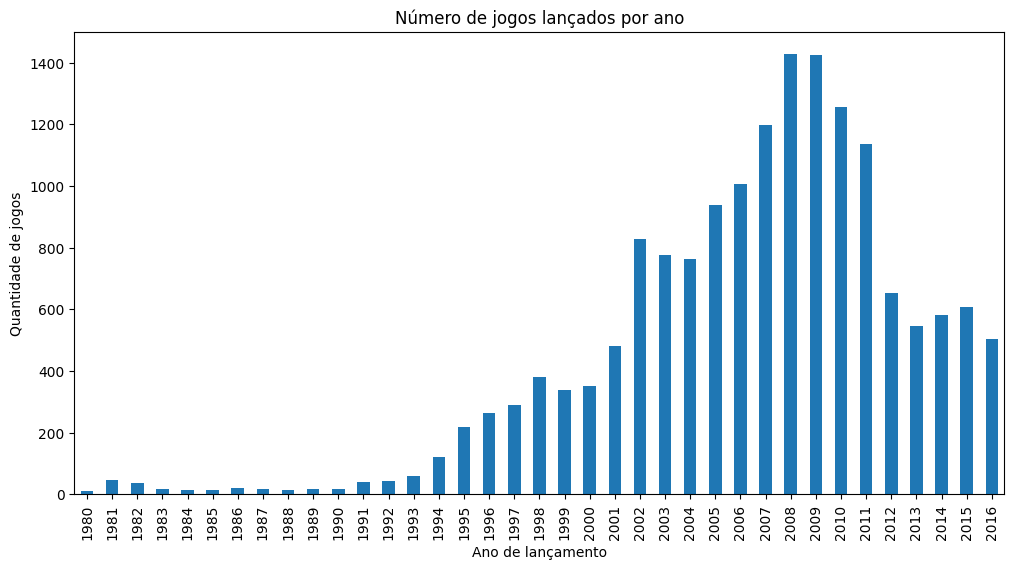

In [121]:
# plotar distribuição de jogos por ano
plt.figure(figsize=(12,6))

games_per_year.plot(kind='bar')

plt.title('Número de jogos lançados por ano')
plt.xlabel('Ano de lançamento')
plt.ylabel('Quantidade de jogos')

plt.show()

Observando o gráfico, é possível notar que o número de jogos lançados por ano cresce gradualmente a partir da década de 1990 e atinge seu pico entre 2008 e 2009.

Após esse período, observa-se uma redução significativa na quantidade de lançamentos registrados no dataset. Essa queda pode estar relacionada a mudanças no mercado, como a consolidação de plataformas ou mudanças na forma de distribuição de jogos.

Também é importante considerar que os dados mais recentes (especialmente 2016) podem estar incompletos, já que o dataset foi coletado antes do final daquele ano.

Dessa forma, os dados anteriores aos anos 2000 podem não ser tão representativos do mercado atual, já que a indústria de videogames passou por grandes transformações ao longo das décadas. Por esse motivo, nas próximas etapas da análise será considerado um período mais recente do dataset para identificar tendências relevantes para o planejamento de 2017.

### Vendas totais por plataforma

Para compreender como o desempenho comercial varia entre diferentes plataformas, é importante analisar o total de vendas acumuladas para cada uma delas.

Essa análise permite identificar quais plataformas tiveram maior sucesso no mercado e ajuda a entender como a popularidade das plataformas evoluiu ao longo do tempo.

In [122]:
# calcular vendas totais por plataforma
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

# visualizar resultado
platform_sales

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64

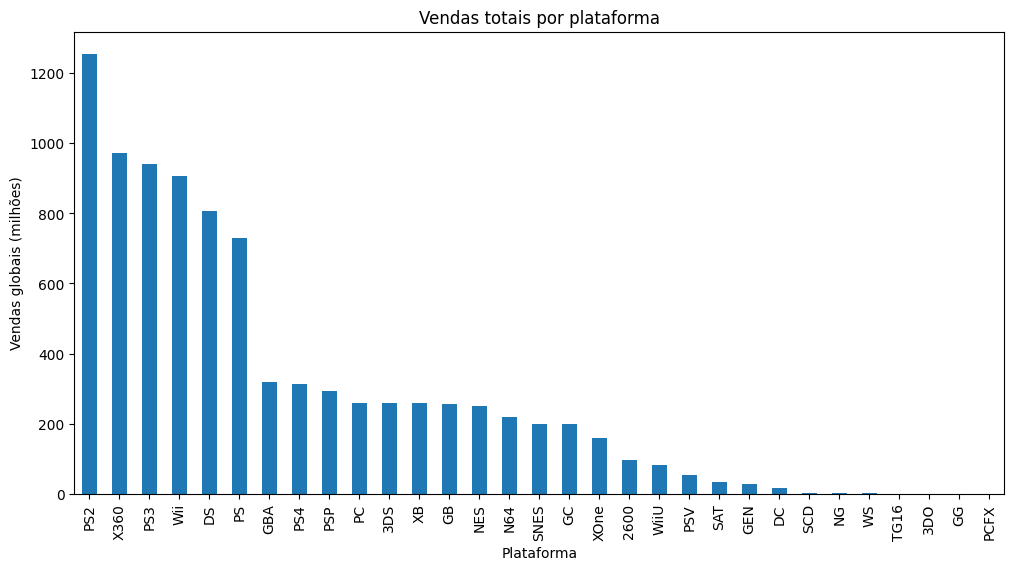

In [123]:
#plotar vendas totais por plataforma
plt.figure(figsize=(12,6))

platform_sales.plot(kind='bar')

plt.title('Vendas totais por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões)')

plt.show()

A análise das vendas totais por plataforma mostra que algumas plataformas dominaram o mercado em determinados períodos.

Plataformas como PlayStation, Xbox e Nintendo apresentam volumes de vendas significativamente maiores do que outras, o que reflete sua forte presença no mercado de videogames ao longo dos anos.

Esse resultado também evidencia que o ciclo de vida das plataformas é um fator importante na análise do mercado, já que novas plataformas surgem, ganham popularidade e eventualmente são substituídas por gerações mais recentes.

### Evolução das vendas por plataforma ao longo do tempo

Para compreender melhor o ciclo de vida das plataformas de videogame, analisaremos como as vendas evoluíram ao longo dos anos para as plataformas com maior volume total de vendas.

Essa análise permite observar padrões como o surgimento de novas plataformas, o período de crescimento das vendas e o momento em que determinadas plataformas começam a perder relevância no mercado.

Para isso, serão selecionadas as plataformas com maiores vendas totais e será construída uma distribuição das vendas por ano para cada uma delas.

In [124]:
# selecionar as plataformas com maior volume de vendas
top_platforms = platform_sales.head(5).index

# visualizar plataformas selecionadas
top_platforms

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS'], dtype='object', name='platform')

In [125]:
# calcular vendas por ano para as principais plataformas
platform_year_sales = df[df['platform'].isin(top_platforms)].pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

# visualizar tabela resultante
platform_year_sales

platform,DS,PS2,PS3,Wii,X360
year_of_release,,,,,
1985,0.02,NaN,NaN,NaN,NaN
2000,NaN,39.17,NaN,NaN,NaN
2001,NaN,166.43,NaN,NaN,NaN
2002,NaN,205.38,NaN,NaN,NaN
2003,NaN,184.31,NaN,NaN,NaN
2004,17.27,211.81,NaN,NaN,NaN
2005,130.14,160.66,NaN,NaN,8.25
2006,119.81,103.42,20.96,137.15,51.62
2007,146.94,75.99,73.19,152.77,95.41


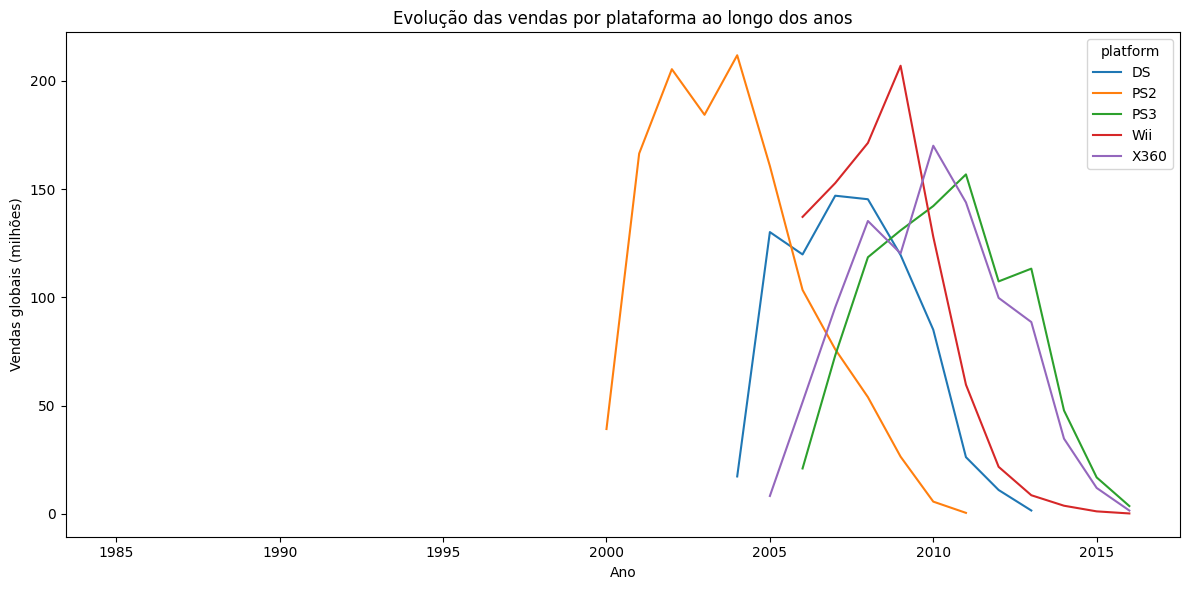

In [126]:
# plotar evolução das vendas por plataforma ao longo dos anos
platform_year_sales.plot(figsize=(12,6))

plt.title('Evolução das vendas por plataforma ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Vendas globais (milhões)')

plt.tight_layout()
plt.show()

### Seleção do período relevante para análise

A análise da evolução das vendas por plataforma mostra que os consoles possuem um ciclo de vida relativamente limitado. Após o lançamento, as vendas crescem rapidamente até atingir um pico e, em seguida, começam a diminuir à medida que novas gerações de consoles são lançadas.

Observa-se que plataformas populares em anos anteriores, como PS2, DS e Wii, perderam relevância ao longo do tempo e perderam relevância significativa no mercado nos anos mais recentes.

Como o objetivo do projeto é identificar padrões que possam ajudar a planejar campanhas para o ano de 2017, é mais adequado concentrar a análise nos anos mais recentes do dataset.

Dessa forma, será considerado o período **de 2012 a 2016**, que representa melhor o estado atual do mercado e inclui as plataformas mais relevantes da geração recente de consoles.

In [127]:
# filtrar dados para o período mais relevante (2012 a 2016)
df_recent = df[df['year_of_release'] >= 2012]

# verificar dimensões do novo dataset 
df_recent.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
34,Call of Duty: Black Ops II,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83.0,5.3,M,13.79


### Filtragem do período relevante

Com base na análise anterior, foi criado um novo conjunto de dados contendo apenas os jogos lançados a partir de 2012.

Esse recorte permite focar em um período mais recente do mercado de videogames, que é mais adequado para identificar tendências relevantes para o planejamento de campanhas em 2017.

Ao remover dados de plataformas muito antigas, reduzimos possíveis distorções na análise e concentramos o estudo nas plataformas que ainda estavam ativas ou relevantes no período analisado.

In [128]:
# filtrar dados a partir de 2012
df_recent = df[df['year_of_release'] >= 2012]

# verificar dimensões do novo dataset
df_recent.shape


(2886, 12)

### Plataformas líderes no período recente

Após definir o período relevante para a análise (2012–2016), o próximo passo é identificar quais plataformas apresentam maior volume de vendas nesse intervalo.

Essa análise permite compreender quais consoles dominam o mercado mais recente e quais plataformas podem apresentar maior potencial comercial para campanhas planejadas para o ano de 2017.

In [129]:
# calcular vendas totais por plataforma no período recente
recent_platform_sales = df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

# visualizar resultado
recent_platform_sales

platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64

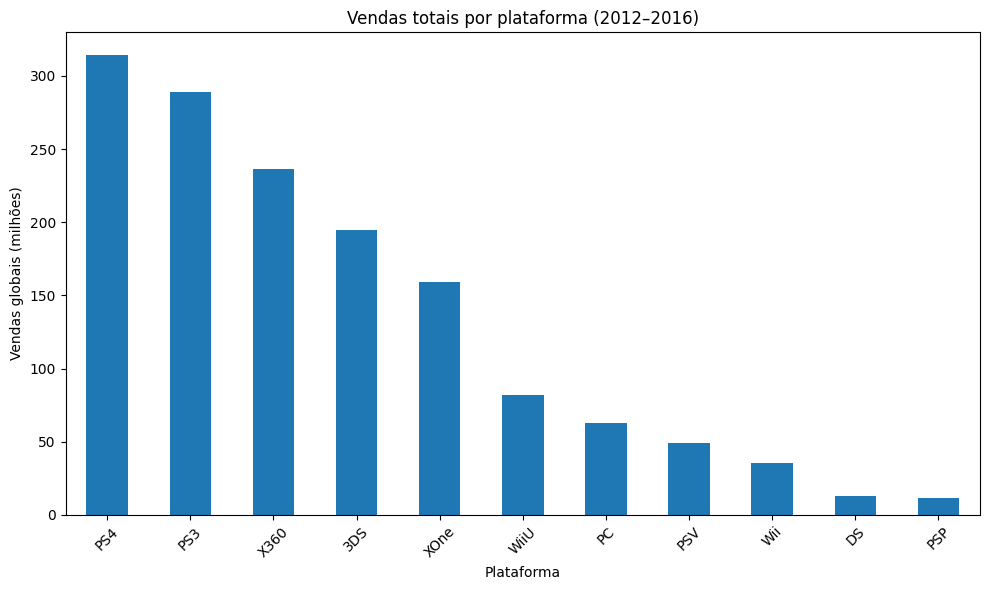

In [130]:
# plotar vendas totais por plataforma no período recente
recent_platform_sales.plot(kind='bar', figsize=(10,6))

plt.title('Vendas totais por plataforma (2012–2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### Interpretação das vendas por plataforma no período recente

A análise das vendas no período entre 2012 e 2016 mostra que as plataformas mais recentes dominam o mercado durante esse intervalo.

O **PlayStation 4 (PS4)** apresenta o maior volume de vendas no período analisado, indicando forte crescimento e consolidação como principal plataforma da geração mais recente. Em seguida aparecem **PS3** e **Xbox 360**, que ainda mantinham um volume significativo de vendas, embora já estivessem em fase de transição para uma nova geração de consoles.

Plataformas como **Nintendo 3DS** e **Xbox One** também apresentam volumes relevantes de vendas, sugerindo que continuam sendo importantes no mercado durante esse período.

Por outro lado, plataformas mais antigas como **Wii, DS e PSP** apresentam volumes muito menores de vendas, indicando que já estavam em fase avançada de declínio no ciclo de vida.

Com base nessa análise, plataformas como **PS4, Xbox One e 3DS** podem ser consideradas particularmente relevantes para análises voltadas ao planejamento de campanhas para o ano de 2017.

Além disso, observa-se que plataformas de gerações anteriores ainda contribuem com volume relevante de vendas, indicando uma transição gradual entre ciclos de consoles.

### Distribuição das vendas globais por plataforma

Para compreender melhor a distribuição das vendas entre diferentes plataformas, será construído um diagrama de caixa (boxplot) utilizando as vendas globais dos jogos.

Esse tipo de gráfico permite observar a mediana das vendas, a dispersão dos dados e a presença de valores extremos (outliers), que representam jogos com desempenho de vendas muito superior à média.

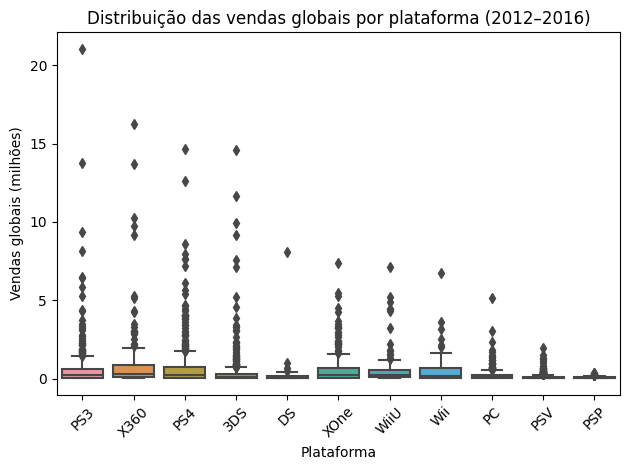

In [131]:
# plotar distribuição das vendas globais por plataforma
sns.boxplot(data=df_recent, x='platform', y='total_sales')

plt.title('Distribuição das vendas globais por plataforma (2012–2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### Interpretação da distribuição das vendas por plataforma

O diagrama de caixa mostra que a maior parte dos jogos apresenta volumes relativamente baixos de vendas globais. Em praticamente todas as plataformas, a mediana das vendas está próxima de valores baixos, indicando que a maioria dos títulos vende menos de 1 milhão de unidades.

Ao mesmo tempo, observa-se a presença de diversos **outliers**, representando jogos com desempenho comercial muito superior à média. Esses títulos concentram grande parte das vendas do mercado, o que sugere que a indústria de videogames é fortemente dependente de poucos grandes sucessos.

Entre as plataformas analisadas, consoles como **PS4, Xbox One, PS3 e Xbox 360** apresentam distribuições com valores máximos mais elevados e maior quantidade de outliers, indicando maior potencial para jogos de grande sucesso comercial.

Já plataformas como **PSV e PSP** apresentam distribuições mais concentradas em valores baixos de vendas, sugerindo menor impacto comercial no período analisado.

De forma geral, os resultados reforçam que plataformas da geração mais recente tendem a oferecer melhores oportunidades para títulos com alto desempenho de vendas.

### Relação entre avaliações e vendas (Plataforma PS4)

Para entender se as avaliações influenciam o desempenho comercial dos jogos, será analisada a relação entre as pontuações de críticos e usuários e as vendas globais.

Como exemplo, será utilizada a plataforma **PS4**, uma das mais relevantes no período recente do dataset. Serão construídos gráficos de dispersão para visualizar a relação entre avaliações e vendas, além de calcular o coeficiente de correlação entre essas variáveis.

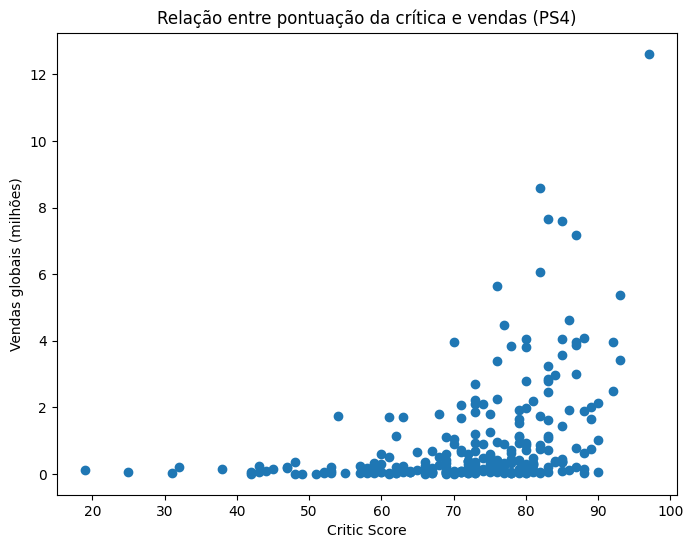

In [132]:
# criar dataset apenas com jogos de PS4
ps4_data = df_recent[df_recent['platform'] == 'PS4']

# plotar relação entre critic_score e vendas
plt.figure(figsize=(8,6))
plt.scatter(ps4_data['critic_score'], ps4_data['total_sales'])

plt.title('Relação entre pontuação da crítica e vendas (PS4)')
plt.xlabel('Critic Score')
plt.ylabel('Vendas globais (milhões)')

plt.show()

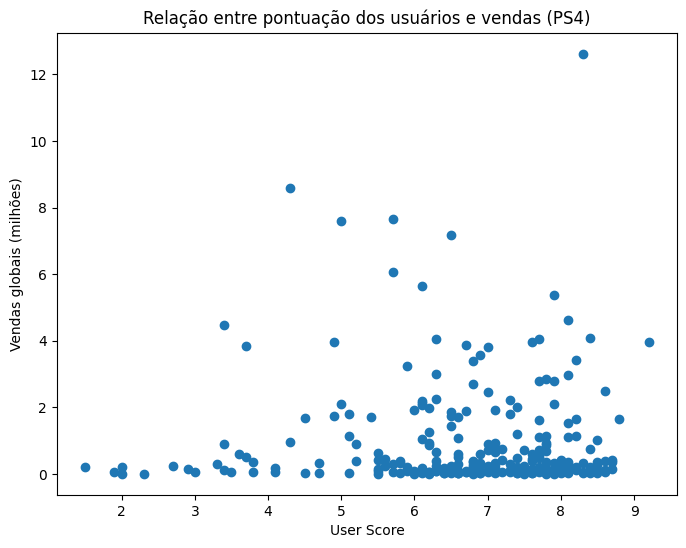

In [133]:
# plotar relação entre user_score e vendas
plt.figure(figsize=(8,6))

plt.scatter(ps4_data['user_score'], ps4_data['total_sales'])

plt.title('Relação entre pontuação dos usuários e vendas (PS4)')
plt.xlabel('User Score')
plt.ylabel('Vendas globais (milhões)')

plt.show()

In [134]:
# calcular correlação entre critic_score e vendas
critic_corr = ps4_data['critic_score'].corr(ps4_data['total_sales'])

# calcular correlação entre user_score e vendas
user_corr = ps4_data['user_score'].corr(ps4_data['total_sales'])

print("Correlação critic_score:", critic_corr)
print("Correlação user_score:", user_corr)


Correlação critic_score: 0.40656790206178095
Correlação user_score: -0.031957110204556376


### Relação entre avaliações e vendas (PS4)

A análise da relação entre avaliações e vendas para jogos da plataforma PS4 evidencia comportamentos distintos entre as pontuações atribuídas por críticos e por usuários.

A correlação entre **critic_score e vendas globais** foi de aproximadamente **0.41**, indicando uma correlação positiva moderada. Esse resultado sugere que jogos com melhores avaliações da crítica tendem, em média, a alcançar maiores volumes de vendas. No entanto, essa relação não é forte o suficiente para ser considerada determinante, o que indica que outros fatores também desempenham um papel relevante no desempenho comercial.

Em contraste, a correlação entre **user_score e vendas globais** foi praticamente inexistente (-0.03). Os gráficos de dispersão reforçam essa conclusão, apresentando uma distribuição aleatória dos dados, sem um padrão claro que indique relação entre essas variáveis.

Esses resultados indicam que a recepção crítica pode influenciar parcialmente o sucesso comercial de um jogo, enquanto as avaliações dos usuários não demonstram impacto significativo nas vendas.

Sob uma perspectiva de negócio, isso sugere que fatores como investimento em marketing, visibilidade no lançamento, força da marca e reconhecimento da franquia podem exercer maior influência no desempenho comercial do que a percepção dos usuários.



### Comparação das vendas entre plataformas

Após analisar a relação entre avaliações e vendas para a plataforma PS4, é interessante verificar se os mesmos jogos apresentam desempenho semelhante em outras plataformas.

Essa comparação permite entender se o sucesso comercial de um jogo depende principalmente da plataforma em que ele é lançado ou se jogos populares tendem a ter bom desempenho independentemente da plataforma.

Para isso, serão comparadas as vendas de jogos lançados simultaneamente em diferentes plataformas.


In [135]:
# criar tabela com vendas por jogo e plataforma
multi_platform = df_recent.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

# visualizar dados
multi_platform.head()


platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Beyblade Burst,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fire Emblem Fates,1.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frozen: Olaf's Quest,0.59,0.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Haikyu!! Cross Team Match!,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tales of Xillia 2,NaN,NaN,NaN,0.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN


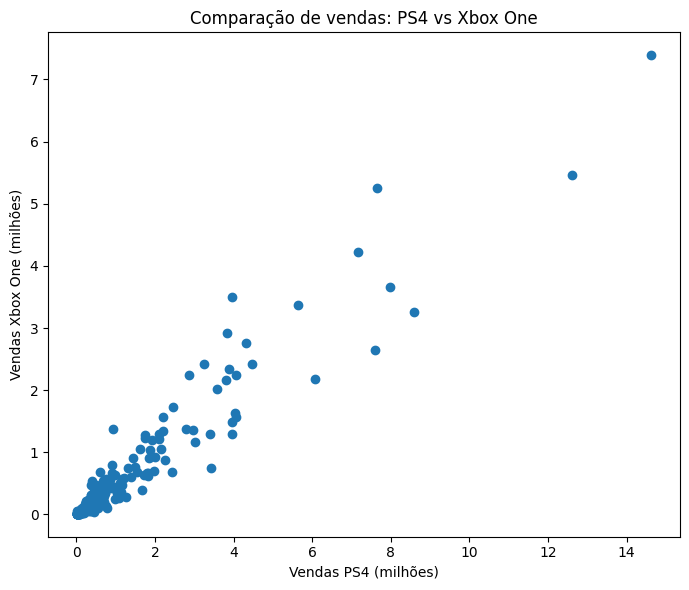

In [136]:
# preparar dados removendo valores ausentes (PS4 vs Xbox One)
ps4_xone = multi_platform[['PS4','XOne']].dropna()

# plotar comparação de vendas entre PS4 e Xbox One
plt.figure(figsize=(7,6))

plt.scatter(ps4_xone['PS4'], ps4_xone['XOne'])

plt.xlabel('Vendas PS4 (milhões)')
plt.ylabel('Vendas Xbox One (milhões)')
plt.title('Comparação de vendas: PS4 vs Xbox One')

plt.tight_layout()
plt.show()


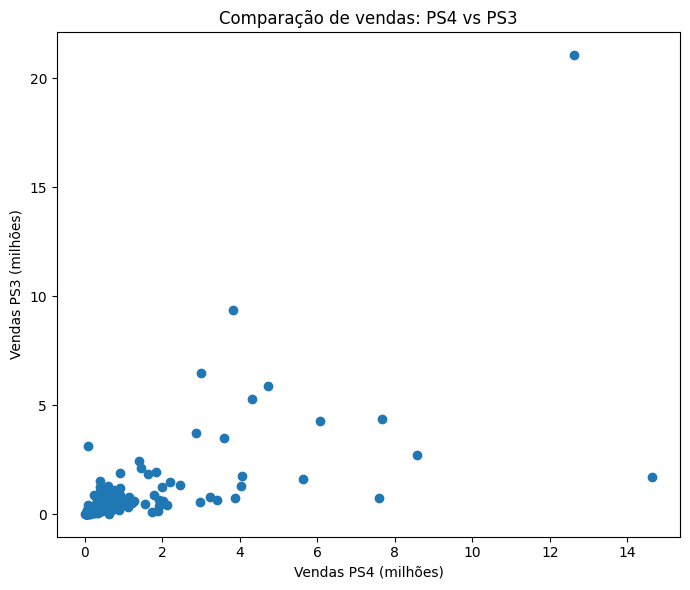

In [137]:
# preparar dados removendo valores ausentes (PS4 vs PS3)
ps4_ps3 = multi_platform[['PS4','PS3']].dropna()

# plotar comparação de vendas entre PS4 e PS3
plt.figure(figsize=(7,6))

plt.scatter(ps4_ps3['PS4'], ps4_ps3['PS3'])

plt.xlabel('Vendas PS4 (milhões)')
plt.ylabel('Vendas PS3 (milhões)')
plt.title('Comparação de vendas: PS4 vs PS3')

plt.tight_layout()
plt.show()


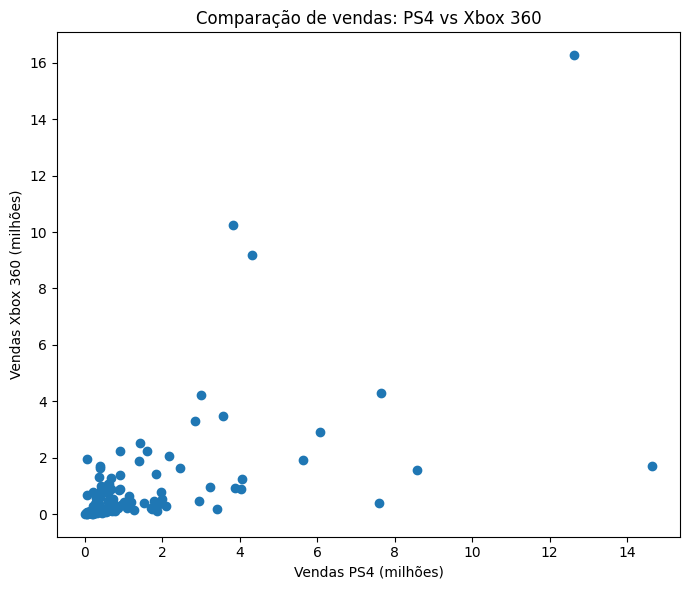

In [138]:
# preparar dados removendo valores ausentes (PS4 vs Xbox 360)
ps4_x360 = multi_platform[['PS4','X360']].dropna()

# plotar comparação de vendas entre PS4 e Xbox 360
plt.figure(figsize=(7,6))

plt.scatter(ps4_x360['PS4'], ps4_x360['X360'])

plt.xlabel('Vendas PS4 (milhões)')
plt.ylabel('Vendas Xbox 360 (milhões)')
plt.title('Comparação de vendas: PS4 vs Xbox 360')

plt.tight_layout()
plt.show()


### Comparação das vendas entre plataformas

Os gráficos de dispersão permitem analisar a relação entre as vendas de um mesmo jogo em diferentes plataformas, com foco na comparação entre PS4 e outros consoles relevantes.

Observa-se uma relação positiva entre as vendas de jogos em **PS4 e Xbox One**, indicando que títulos populares tendem a apresentar bom desempenho comercial em ambas as plataformas. Isso reflete o fato de que muitos jogos são lançados simultaneamente para múltiplos consoles, permitindo que o sucesso de um título se replique em diferentes mercados.

Na comparação entre **PS4 e PS3**, a relação se torna menos evidente, possivelmente devido à transição entre gerações de consoles. Enquanto o PS3 pertence à geração anterior, o PS4 representa uma plataforma mais recente, o que impacta diretamente o volume de vendas e a adoção pelos usuários.

Já na comparação entre **PS4 e Xbox 360**, a relação é ainda mais fraca, refletindo o estágio avançado do ciclo de vida do Xbox 360 durante o período analisado. Nesse contexto, jogos lançados nessa plataforma tendem a apresentar menor desempenho comercial em comparação com consoles mais recentes.

De forma geral, os resultados indicam que jogos bem-sucedidos tendem a performar bem em múltiplas plataformas, mas o potencial de vendas está fortemente associado ao momento do ciclo de vida da plataforma e à sua relevância no mercado.


### Análise das vendas por gênero

Para compreender quais tipos de jogos apresentam melhor desempenho comercial, será analisada a distribuição das vendas globais por gênero.

Essa análise permite identificar quais gêneros concentram maior volume de vendas no mercado, bem como avaliar o desempenho médio por título. Essa distinção é importante, pois um gênero pode ter alto volume total devido à quantidade de lançamentos, mas não necessariamente apresentar alto desempenho médio por jogo.


In [139]:
# calcular vendas totais por gênero
genre_sales = df_recent.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

# visualizar resultado
genre_sales


genre
Action          441.12
Shooter         304.73
Role-Playing    192.80
Sports          181.07
Misc             85.04
Platform         61.00
Racing           53.50
Fighting         44.49
Simulation       35.12
Adventure        29.43
Strategy         13.34
Puzzle            4.89
Name: total_sales, dtype: float64

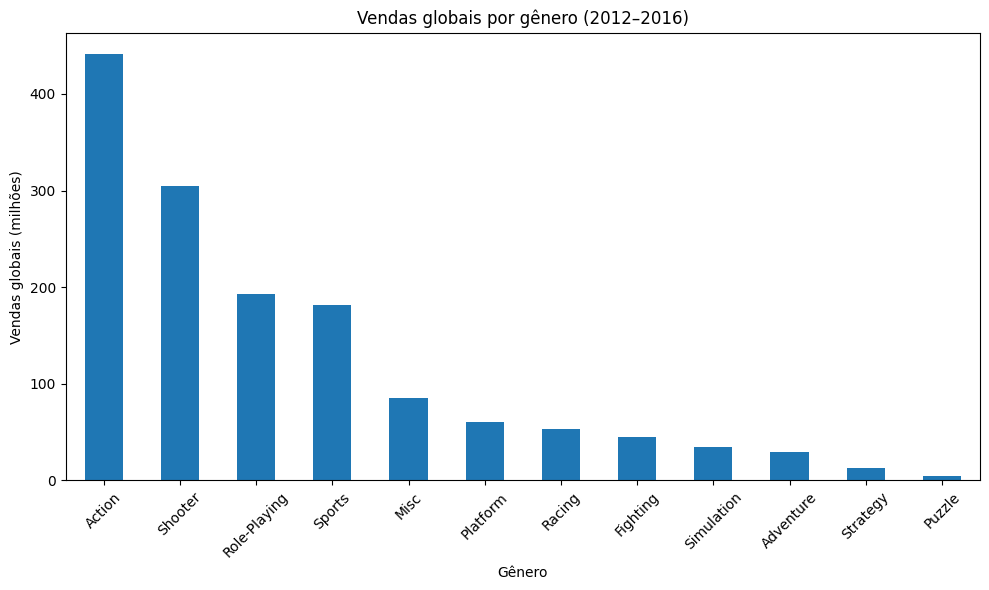

In [140]:
# plotar vendas globais por gênero
genre_sales.plot(kind='bar', figsize=(10,6))

plt.title('Vendas globais por gênero (2012–2016)')
plt.xlabel('Gênero')
plt.ylabel('Vendas globais (milhões)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [141]:
# calcular vendas médias por jogo em cada gênero
genre_mean_sales = df_recent.groupby('genre')['total_sales'].mean().sort_values(ascending=False)

# visualizar resultado
genre_mean_sales

genre
Shooter         1.296723
Platform        0.717647
Sports          0.675634
Role-Playing    0.521081
Racing          0.465217
Misc            0.442917
Simulation      0.439000
Action          0.427856
Fighting        0.408165
Strategy        0.187887
Puzzle          0.174643
Adventure       0.097450
Name: total_sales, dtype: float64

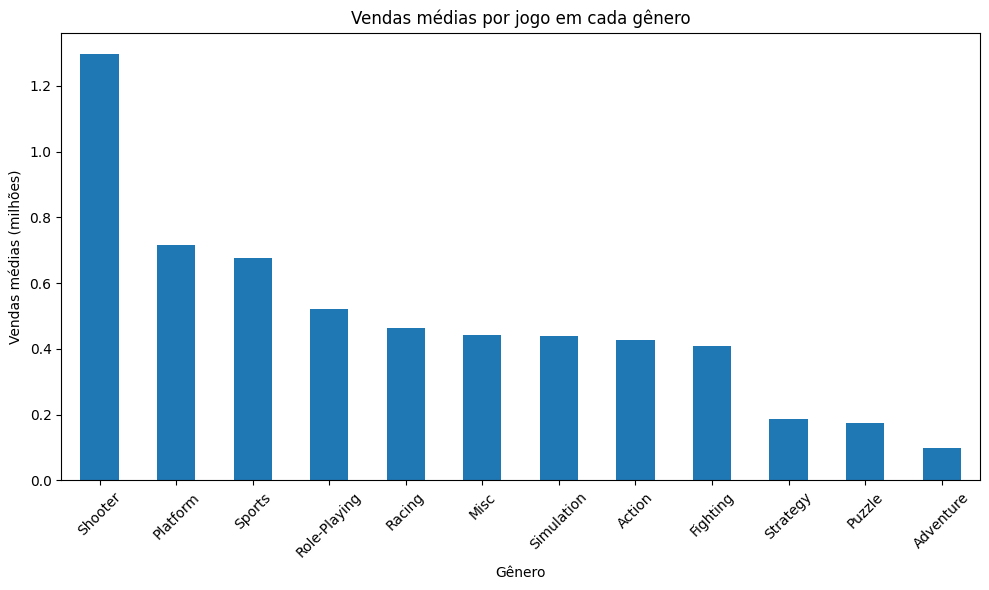

In [142]:
# plotar vendas médias por gênero
genre_mean_sales.plot(kind='bar', figsize=(10,6))

plt.title('Vendas médias por jogo em cada gênero')
plt.xlabel('Gênero')
plt.ylabel('Vendas médias (milhões)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### Interpretação das vendas por gênero

A análise das vendas por gênero revela diferenças relevantes tanto no volume total quanto no desempenho médio dos jogos.

Em termos de **volume total de vendas**, o gênero **Action** lidera o mercado, seguido por **Shooter**, **Role-Playing** e **Sports**. Esse resultado está relacionado, em parte, à maior quantidade de títulos lançados nesses gêneros, o que contribui para o volume acumulado de vendas.

No entanto, ao analisar as **vendas médias por jogo**, observa-se um comportamento distinto. O gênero **Shooter** apresenta a maior média de vendas por título, indicando que jogos desse tipo tendem a alcançar maior sucesso comercial individualmente.

Gêneros como **Platform** e **Sports** também demonstram bom desempenho médio, enquanto **Adventure**, **Puzzle** e **Strategy** apresentam médias significativamente menores, sugerindo menor potencial comercial por título.

De forma geral, os resultados indicam que gêneros como **Shooter, Action e Sports** possuem maior potencial de retorno comercial, seja pelo volume total de vendas ou pelo desempenho médio dos jogos. Em contrapartida, gêneros como **Adventure e Puzzle** tendem a apresentar menor impacto no mercado.

Sob a perspectiva estratégica, esses insights podem orientar decisões relacionadas ao posicionamento de produtos, priorização de investimentos e definição de campanhas de marketing.


## Perfil de usuário por região

O mercado global de videogames apresenta diferenças importantes entre regiões. Preferências por plataformas, gêneros e classificações etárias podem variar significativamente entre América do Norte, Europa e Japão.

Nesta etapa será analisado o comportamento dos consumidores em cada região para identificar padrões específicos de mercado. Para isso, serão avaliados:

- As cinco plataformas com maiores vendas em cada região
- Os cinco gêneros mais populares
- O impacto das classificações ESRB nas vendas

Essa análise permite compreender diferenças regionais e identificar oportunidades estratégicas para campanhas de marketing direcionadas.

In [143]:
# calcular top 5 plataformas por região (vendas totais)
na_platforms = df_recent.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_platforms = df_recent.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_platforms = df_recent.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

# visualizar resultados
na_platforms, eu_platforms, jp_platforms


(platform
 X360    140.05
 PS4     108.74
 PS3     103.38
 XOne     93.12
 3DS      55.31
 Name: na_sales, dtype: float64,
 platform
 PS4     141.09
 PS3     106.86
 X360     74.52
 XOne     51.59
 3DS      42.64
 Name: eu_sales, dtype: float64,
 platform
 3DS     87.79
 PS3     35.29
 PSV     21.04
 PS4     15.96
 WiiU    13.01
 Name: jp_sales, dtype: float64)

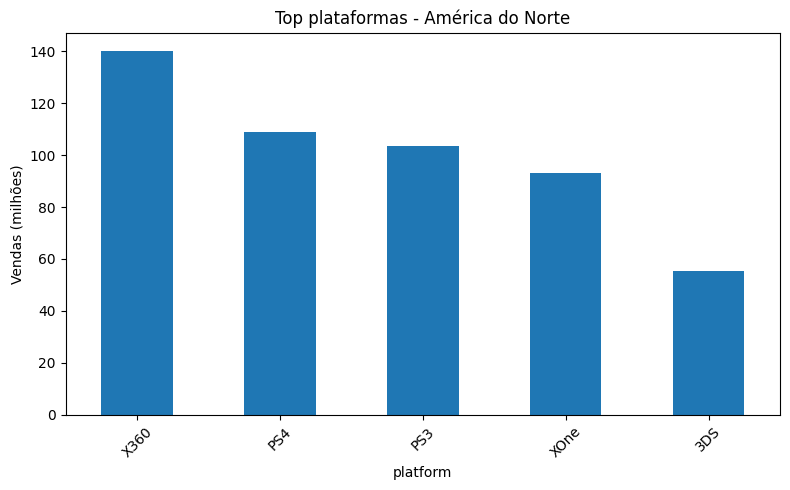

In [144]:
# plotar top plataformas - América do Norte
na_platforms.plot(kind='bar', figsize=(8,5))

plt.title('Top plataformas - América do Norte')
plt.ylabel('Vendas (milhões)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


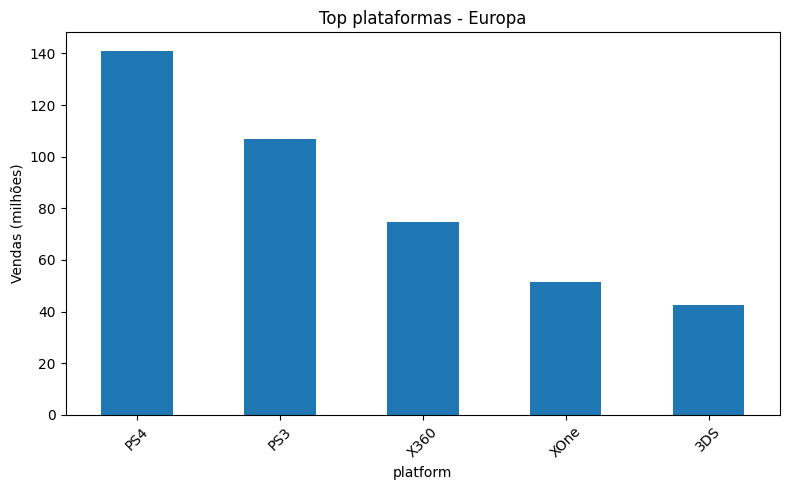

In [145]:
# plotar top plataformas - Europa
eu_platforms.plot(kind='bar', figsize=(8,5))

plt.title('Top plataformas - Europa')
plt.ylabel('Vendas (milhões)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


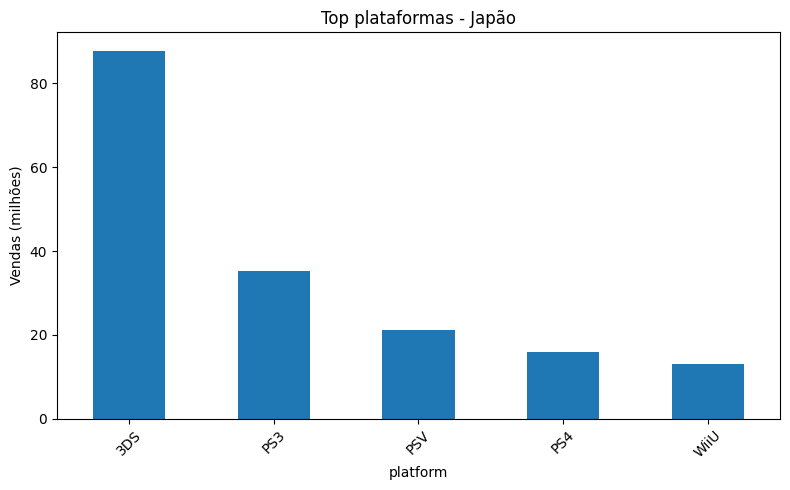

In [146]:
# plotar top plataformas - Japão
jp_platforms.plot(kind='bar', figsize=(8,5))

plt.title('Top plataformas - Japão')
plt.ylabel('Vendas (milhões)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### Plataformas mais populares por região

A análise das plataformas mais vendidas em cada região revela diferenças significativas no comportamento dos consumidores entre América do Norte, Europa e Japão.

Na **América do Norte**, o Xbox 360 lidera as vendas, seguido por PS4 e PS3. Esse resultado indica uma forte presença dos consoles da Microsoft nesse mercado, além da predominância de consoles domésticos.

Na **Europa**, o PS4 apresenta o maior volume de vendas, seguido por PS3 e Xbox 360. Isso sugere uma maior preferência pelos consoles da Sony, que demonstram forte consolidação no mercado europeu.

Já no **Japão**, observa-se um padrão bastante distinto. A plataforma mais popular é o **Nintendo 3DS**, seguida por PS3 e PSV. Diferentemente das outras regiões, há uma forte presença de consoles portáteis, refletindo preferências culturais e hábitos de consumo específicos do mercado japonês.

De forma geral, os resultados indicam que o desempenho das plataformas varia significativamente entre regiões, reforçando a importância de adaptar estratégias de lançamento e marketing de acordo com as características de cada mercado.


### Gêneros mais populares por região

Além das diferenças entre plataformas, as preferências por gênero de jogos também podem variar entre regiões. 

Nesta etapa serão analisados os gêneros com maior volume de vendas em cada mercado regional: América do Norte, Europa e Japão.

Essa análise ajuda a compreender as preferências do público em diferentes partes do mundo e pode orientar estratégias de desenvolvimento e marketing de jogos para cada região.

In [147]:
# calcular top 5 gêneros por região (vendas totais)
na_genres = df_recent.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_genres = df_recent.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_genres = df_recent.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

# visualizar resultados
na_genres, eu_genres, jp_genres


(genre
 Action          177.84
 Shooter         144.77
 Sports           81.53
 Role-Playing     64.00
 Misc             38.19
 Name: na_sales, dtype: float64,
 genre
 Action          159.34
 Shooter         113.47
 Sports           69.09
 Role-Playing     48.53
 Racing           27.29
 Name: eu_sales, dtype: float64,
 genre
 Role-Playing    65.44
 Action          52.80
 Misc            12.86
 Simulation      10.41
 Fighting         9.44
 Name: jp_sales, dtype: float64)

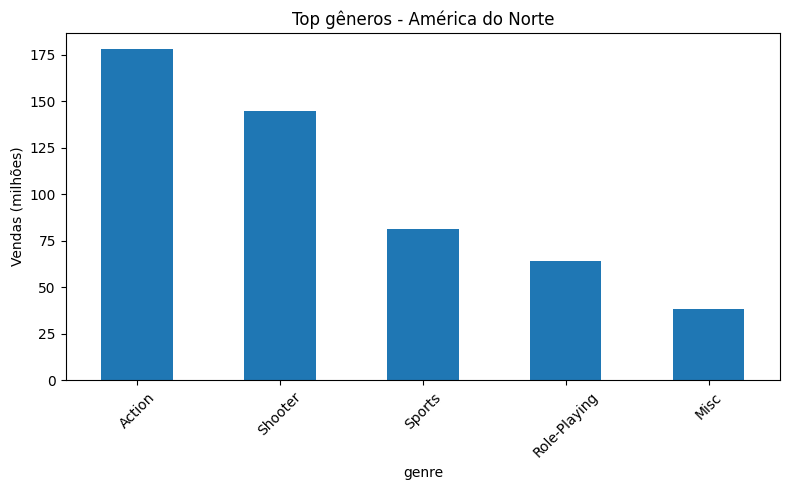

In [148]:
# plotar top gêneros - América do Norte
na_genres.plot(kind='bar', figsize=(8,5))

plt.title('Top gêneros - América do Norte')
plt.ylabel('Vendas (milhões)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


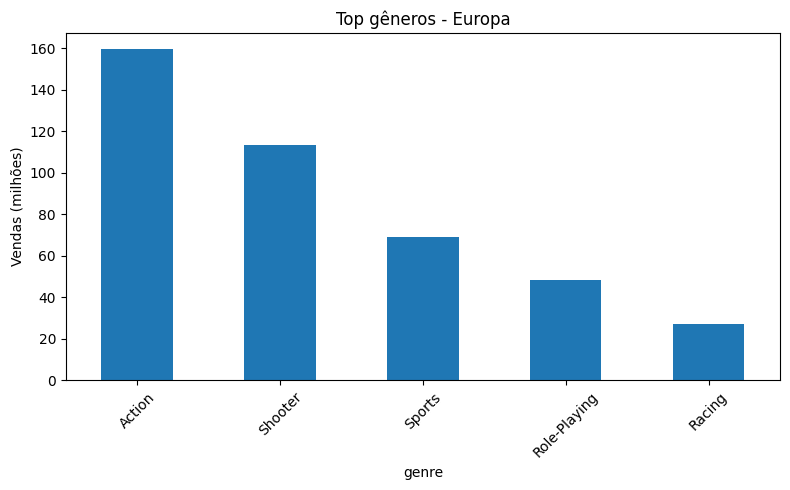

In [149]:
# plotar top gêneros - Europa
eu_genres.plot(kind='bar', figsize=(8,5))

plt.title('Top gêneros - Europa')
plt.ylabel('Vendas (milhões)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


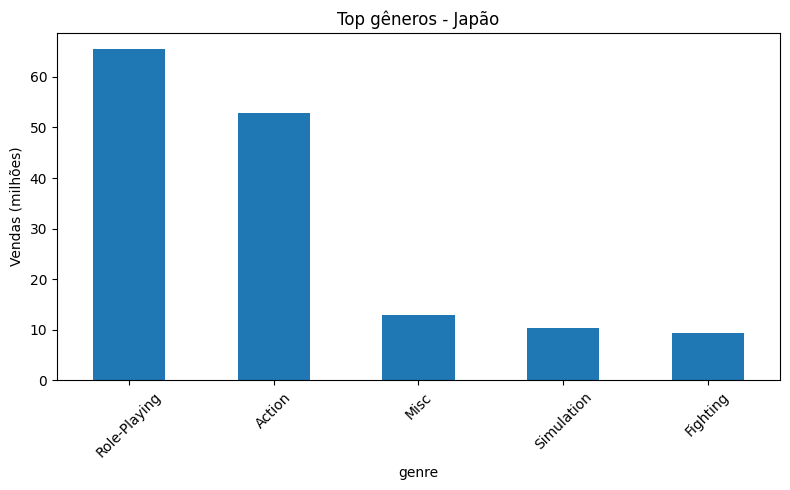

In [150]:
# plotar top gêneros - Japão
jp_genres.plot(kind='bar', figsize=(8,5))

plt.title('Top gêneros - Japão')
plt.ylabel('Vendas (milhões)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### Gêneros mais populares por região

Além das diferenças entre plataformas, as preferências por gênero de jogos também variam significativamente entre regiões.

A análise dos gêneros mais vendidos em cada mercado revela padrões distintos de comportamento do consumidor na América do Norte, Europa e Japão.

Na **América do Norte**, os gêneros mais populares são **Action, Shooter e Sports**, que costumam estar associados a jogos de ritmo acelerado, experiências competitivas e franquias de grande escala. Esses gêneros frequentemente recebem altos investimentos em marketing e possuem forte apelo comercial.

Na **Europa**, observa-se um padrão bastante semelhante, com **Action, Shooter e Sports** também liderando as vendas. A presença do gênero **Racing** entre os mais relevantes sugere uma maior afinidade do público europeu por jogos de corrida, que possuem tradição nesse mercado.

Já no **Japão**, o comportamento do consumidor é significativamente diferente. O gênero **Role-Playing (RPG)** domina as vendas, refletindo a forte tradição desse tipo de jogo no mercado japonês, além da influência de desenvolvedores locais. Outros gêneros como **Action, Simulation e Fighting** também aparecem entre os mais relevantes.

De forma geral, os resultados demonstram que as preferências por gênero variam de acordo com características culturais e hábitos de consumo regionais. Esses insights são fundamentais para orientar estratégias de desenvolvimento de produtos e campanhas de marketing adaptadas a cada mercado.


### Impacto da classificação ESRB nas vendas

A classificação ESRB indica a faixa etária recomendada para os jogos e pode influenciar o público-alvo e o desempenho comercial de um título.

Nesta etapa será analisado como diferentes classificações etárias estão associadas ao volume de vendas nas principais regiões do mercado: América do Norte, Europa e Japão.

Essa análise ajuda a compreender se determinados tipos de jogos apresentam maior aceitação em mercados específicos.

In [153]:
# remover registros sem classificação ESRB
df_recent_rating = df_recent.dropna(subset=['rating'])

# calcular vendas por classificação ESRB em cada região
na_rating = df_recent_rating.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
eu_rating = df_recent_rating.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
jp_rating = df_recent_rating.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

# visualizar resultados
na_rating, eu_rating, jp_rating


(rating
 M       231.57
 E       114.37
 E10+     75.70
 T        66.02
 Name: na_sales, dtype: float64,
 rating
 M       193.96
 E       113.03
 E10+     55.37
 T        52.96
 Name: eu_sales, dtype: float64,
 rating
 E       28.33
 T       26.02
 M       21.20
 E10+     8.19
 Name: jp_sales, dtype: float64)

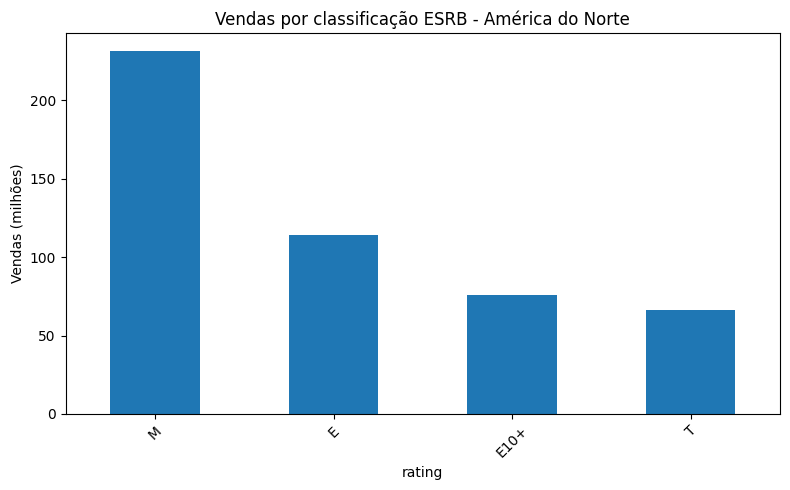

In [154]:
# plotar vendas por classificação ESRB - América do Norte
na_rating.plot(kind='bar', figsize=(8,5))

plt.title('Vendas por classificação ESRB - América do Norte')
plt.ylabel('Vendas (milhões)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


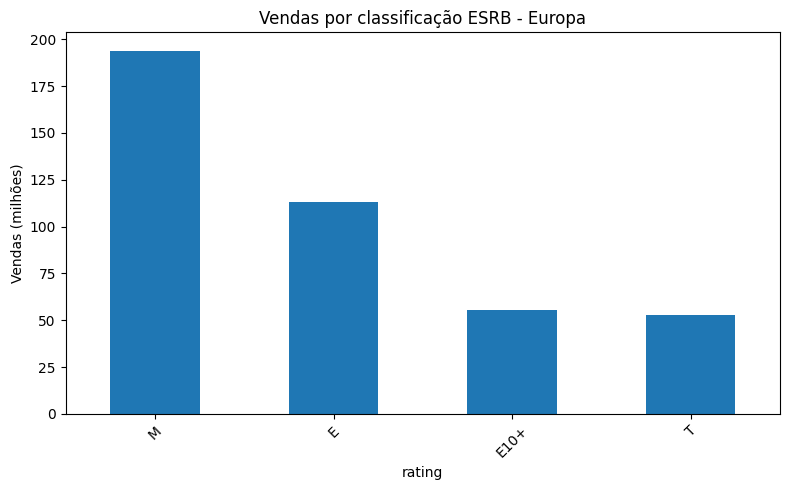

In [155]:
# plotar vendas por classificação ESRB - Europa
eu_rating.plot(kind='bar', figsize=(8,5))

plt.title('Vendas por classificação ESRB - Europa')
plt.ylabel('Vendas (milhões)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


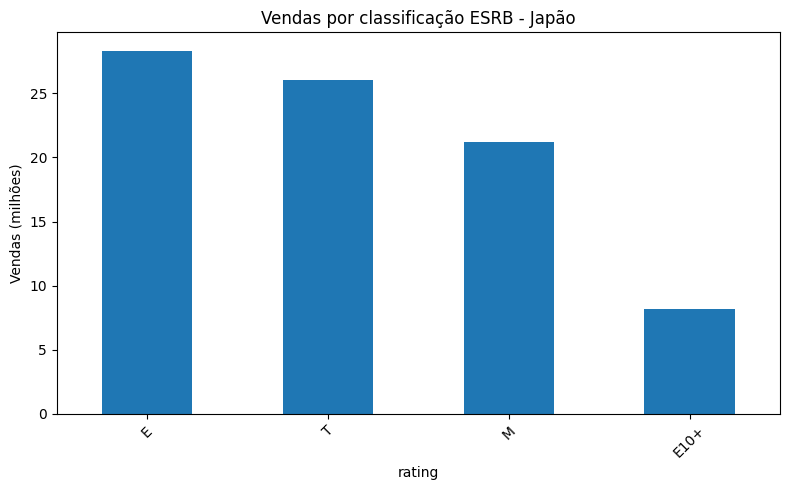

In [156]:
# plotar vendas por classificação ESRB - Japão
jp_rating.plot(kind='bar', figsize=(8,5))

plt.title('Vendas por classificação ESRB - Japão')
plt.ylabel('Vendas (milhões)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### Impacto da classificação ESRB nas vendas por região

A análise das vendas por classificação ESRB revela diferenças relevantes no comportamento dos consumidores entre as principais regiões.

Na **América do Norte**, jogos classificados como **M (Mature)** apresentam o maior volume de vendas, indicando forte preferência por títulos voltados ao público adulto. Jogos classificados como **E (Everyone)** também apresentam participação significativa, mas com menor volume.

Na **Europa**, observa-se um padrão semelhante ao da América do Norte. Jogos classificados como **M** lideram as vendas, seguidos por **E** e **E10+**, reforçando a preferência por títulos com maior complexidade temática e conteúdo mais maduro.

Em contraste, no **Japão**, o comportamento do mercado é distinto. Jogos classificados como **E (Everyone)** apresentam o maior volume de vendas, seguidos por **T (Teen)**. Esse padrão sugere uma maior aceitação de jogos com classificação mais ampla, frequentemente associados a franquias tradicionais e títulos voltados para diferentes faixas etárias.

De forma geral, os resultados indicam que a classificação etária exerce influência no desempenho comercial dos jogos, mas essa influência varia de acordo com o contexto cultural e as preferências regionais dos consumidores. Esses insights são relevantes para a definição de estratégias de posicionamento e segmentação de mercado.


## Teste de hipóteses

### Hipótese 1: Comparação entre Xbox One e PC

Será testada a hipótese de que as classificações médias dos usuários para jogos das plataformas Xbox One e PC são iguais.

- **Hipótese nula (H0):** As médias das avaliações dos usuários são iguais para Xbox One e PC.
- **Hipótese alternativa (H1):** As médias das avaliações dos usuários são diferentes para Xbox One e PC.

Será utilizado um nível de significância de **α = 0.05**, que é um valor padrão em testes estatísticos e representa uma probabilidade de 5% de rejeitar incorretamente a hipótese nula.


In [157]:
# selecionar avaliações de usuários para Xbox One e PC (removendo valores ausentes)
xone_scores = df_recent[df_recent['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df_recent[df_recent['platform'] == 'PC']['user_score'].dropna()


In [158]:
# importar biblioteca estatística
from scipy import stats

# definir nível de significância
alpha = 0.05

# aplicar teste t de Student (variâncias diferentes)
results = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)

# exibir p-value
print("p-value:", results.pvalue)


p-value: 0.5489537965134912


In [159]:
# interpretar resultado do teste
if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")


Não rejeitamos a hipótese nula


### Resultado do teste de hipótese 1

O teste estatístico resultou em um valor de p-value de aproximadamente **0.55**, que é superior ao nível de significância adotado (α = 0.05).

Dessa forma, **não rejeitamos a hipótese nula**.

Isso indica que não há evidências estatísticas suficientes para afirmar que as classificações médias dos usuários diferem entre as plataformas Xbox One e PC.

Em termos práticos, os resultados sugerem que o comportamento das avaliações dos usuários é semelhante entre essas duas plataformas no período analisado, indicando que a plataforma, isoladamente, não parece ser um fator determinante para a percepção dos usuários em relação aos jogos.


### Hipótese 2: Comparação entre gêneros Action e Sports

Será testada a hipótese de que as classificações médias dos usuários para jogos dos gêneros Action e Sports são diferentes.

- **Hipótese nula (H0):** As médias das avaliações dos usuários são iguais para os gêneros Action e Sports.
- **Hipótese alternativa (H1):** As médias das avaliações dos usuários são diferentes para os gêneros Action e Sports.

Será utilizado o mesmo nível de significância de **α = 0.05**.


In [160]:
# selecionar avaliações de usuários para os gêneros Action e Sports (removendo valores ausentes)
action_scores = df_recent[df_recent['genre'] == 'Action']['user_score'].dropna()
sports_scores = df_recent[df_recent['genre'] == 'Sports']['user_score'].dropna()


In [161]:
# aplicar teste t de Student para comparar os dois grupos
results = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

# exibir p-value
print("p-value:", results.pvalue)


p-value: 4.24307776572644e-20


In [162]:
# interpretar resultado do teste
if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")


Rejeitamos a hipótese nula


### Resultado do teste de hipótese 2

O teste estatístico resultou em um valor de p-value extremamente baixo (**≈ 4.24 × 10⁻²⁰**), significativamente inferior ao nível de significância adotado (α = 0.05).

Dessa forma, **rejeitamos a hipótese nula**.

Isso indica que há evidências estatísticas suficientes para afirmar que as classificações médias dos usuários diferem entre os gêneros Action e Sports.

Em termos práticos, esse resultado sugere que a percepção dos usuários varia de acordo com o gênero do jogo. Essa diferença pode estar associada a fatores como expectativas distintas do público, características específicas de gameplay ou padrões de qualidade percebida em cada categoria.

Esse tipo de insight é relevante para estratégias de posicionamento e desenvolvimento de produtos, pois indica que o gênero pode influenciar diretamente a experiência percebida pelos usuários.


## Conclusão Geral

Este projeto teve como objetivo identificar padrões que influenciam o sucesso comercial de jogos, com base em dados históricos de vendas, avaliações, plataformas e gêneros, em um cenário hipotético de planejamento estratégico.

A análise exploratória evidenciou que o mercado de videogames é altamente dinâmico, com mudanças constantes impulsionadas por novas gerações de consoles e transformações no comportamento do consumidor. Observou-se que plataformas apresentam um ciclo de crescimento, pico de vendas e posterior declínio, reforçando a necessidade de focar em dados mais recentes para análises relevantes.

Com base nisso, foi definido o período de **2012 a 2016** como o mais adequado para a análise, por representar melhor o contexto de mercado próximo ao momento de decisão.

Entre as plataformas analisadas, **PS4, Xbox One e Nintendo 3DS** se destacam como as mais relevantes no período recente, com o **PS4 liderando em volume de vendas**. Plataformas de gerações anteriores, como PS3 e Xbox 360, ainda apresentam participação significativa, porém com sinais claros de queda.

A análise da distribuição de vendas revelou um mercado altamente concentrado, no qual poucos títulos de grande sucesso são responsáveis por uma parcela relevante das vendas totais. A maioria dos jogos apresenta desempenho comercial mais modesto, indicando alta competitividade e dependência de grandes lançamentos.

Em relação às avaliações, foi identificado que as **pontuações da crítica apresentam correlação positiva moderada com as vendas**, sugerindo que a recepção crítica pode influenciar o desempenho comercial. Por outro lado, as **avaliações dos usuários não demonstraram correlação significativa**, indicando que fatores como marketing, reconhecimento de marca e distribuição podem ter maior impacto nas vendas.

A comparação entre plataformas mostrou que jogos populares tendem a apresentar bom desempenho em múltiplos consoles, especialmente quando lançados simultaneamente. No entanto, plataformas mais recentes concentram maior volume de vendas, reforçando seu papel estratégico no mercado.

A análise por gênero indicou que **Action e Shooter lideram em volume total de vendas**, enquanto o gênero **Shooter apresenta maior média de vendas por jogo**, evidenciando alto potencial comercial por título. Em contraste, gêneros como **Adventure e Puzzle** apresentam menor desempenho médio.

A análise regional revelou diferenças importantes no comportamento do consumidor. América do Norte e Europa apresentam padrões semelhantes, com preferência por jogos de ação, tiro e esportes, além de maior consumo de títulos classificados como "Mature". Já o Japão apresenta um perfil distinto, com maior relevância de jogos do gênero Role-Playing e maior presença de plataformas portáteis.

Por fim, os testes de hipóteses indicaram que:
- Não há diferença estatisticamente significativa entre as avaliações médias de usuários das plataformas Xbox One e PC
- Há diferença estatisticamente significativa entre as avaliações dos gêneros Action e Sports

De forma geral, os resultados indicam que o sucesso de um jogo é influenciado por múltiplos fatores, incluindo plataforma, gênero, região e recepção crítica. 

Para fins estratégicos, recomenda-se:
- Priorizar plataformas mais recentes e em crescimento
- Investir em gêneros com maior potencial comercial, como Action e Shooter
- Adaptar estratégias de marketing de acordo com preferências regionais
- Considerar o impacto da crítica especializada no posicionamento de lançamentos

Este estudo demonstra como a análise de dados pode apoiar decisões mais informadas no planejamento de campanhas e na identificação de oportunidades de mercado.
